# **<p align="center"> Xi 1 Angle of Residues Analysis </p>**

## <ins> Description </ins>
### Explanation

<details open>
<summary> <font size="6"> <ins>Key Points 2 </ins> </font> </summary>

- bulletpoint1

-  bulletpoint1

- [link]()

- image1: <img src="" width = 50%>

</details>

</br>

<details open>
<summary> <font size = "6"> <ins> Key Points 2 </ins> </font> </summary>

- `bulletpoint1`


- `bulletpoint2`



</details>

</br>


In [29]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator
# General Purpose Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
# Molecular Libraries
import gemmi 
# from rdkit import Chem
# import parasail
# Local Libraries
from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats,  get_res_CoM , get_atom_coord
from xaidar.data.molecModels import flatten_pdb, createPDB, clear_empty
from xaidar.data.molecModels import sele_pdb, sele_Lig, sele_AA, sele_chain_name

In [8]:
# Test python objs
test_pdb_path = rootdir.joinpath("data/ev2a/fragalysis/02-chemofint/reference/A0926a.pdb")
test_pdb = loadPDB(test_pdb_path)
test_prot = sele_pdb( test_pdb, sele_AA)
test_prot_mon = sele_pdb( test_prot, sele_chain_name, chain_name = "A")
test_lig = sele_pdb( test_pdb, sele_Lig)
test_chain = flatten_pdb( test_prot_mon, "chain" )
test_res = test_chain[0][0] 
test_atom =  test_res[0]

## <ins> Step 1: Prepare the Proteins <ins>

<details open>
<summary> Stages: </summary>

- Sort **Piperidine Series Proteins** -> Find protein subset and chain with binding site closest to its piperidine -> find  

    - Get the CoM of all Piperidines in Binding Site

        - Gotta account for Piperidines that bind to multiple sites

    - Get the amino acid indexes for the binding site amino acids based off of the reference protein (A0926a) and the Center of Mass of all Piperidines in the Binding Site
    
    - Get the chain with binding site CoM closest to th



- Sort **NOT Piperidine Series Protein**

    - Get one protein per dataset

        - In some cases there are: several subsets per dataset & several protein chains per subset
    
    - Method:

        - Get protein chain from all chains and all subsets, which Center of Mass is closest to the Reference Center of Mass

        - If protein has ligand binding in multiple sites, make sure you move them to the 

            - Use crystallographic data and align with reference aligned data

</details>

### - 1.1: Calculate mean CoM for Piperidine Ligands (mean_CoM)

<details open>
<summary> Steps: </summary>

- Get CoM for Piperidines from datasets with one unique subset

    - Frequency shows this accounts for a significant amount of piperidines (242 / 347)

    - Histogram shows that datasets with single subsets co-localize in the same region (prob ensured by XCA)

- Use this CoM to subset with Piperidine closests to the CoM

    - Histogram shows again that these are all quite close to each other, suggesting that for each dataset, there is always one subset with a piperidine bound to the main binding site

- Update the CoM for the co-localized Filtered Piperidines
</details>

In [9]:
rootdir
piperid_dir = rootdir.joinpath( "data/ev2a/fragalysis/02-chemofint/piperid")

# Get name of datasets with and without multiplicity
from collections import defaultdict
multiplicity_counter = defaultdict(list)
for item in  piperid_dir.iterdir(): multiplicity_counter[item.name[:-1]].append( item.name )

single_datasets = { dataset : lst_subsets for dataset, lst_subsets in multiplicity_counter.items() if len(lst_subsets) == 1 } 
multiple_datasets =  { dataset : lst_subsets for dataset, lst_subsets in multiplicity_counter.items() if len(lst_subsets) > 1 } 

print("Number of datasets with single subsets:   {}".format( single_datasets.__len__() ) )
print("Number of datasets with mulitple subsets: {}".format( multiple_datasets.__len__()) )
print("Total Number of unique datasets: \t  {}".format( single_datasets.__len__()  +  multiple_datasets.__len__() ))

Number of datasets with single subsets:   242
Number of datasets with mulitple subsets: 105
Total Number of unique datasets: 	  347


In [10]:
print(sorted([ subset for lst in multiple_datasets.values() for subset in lst]))

['A3509a', 'A3509b', 'A3557a', 'A3557b', 'A3571a', 'A3571b', 'A3616a', 'A3616b', 'A3706a', 'A3706b', 'A3884a', 'A3884b', 'A3963a', 'A3963b', 'A3986a', 'A3986b', 'A3993a', 'A3993b', 'A4012a', 'A4012b', 'A4017a', 'A4017b', 'A4020a', 'A4020b', 'A4031a', 'A4031b', 'A4035a', 'A4035b', 'A4202a', 'A4202b', 'A4207a', 'A4207b', 'A4214a', 'A4214b', 'A4237a', 'A4237b', 'A4274a', 'A4274b', 'A4283a', 'A4283b', 'A4303a', 'A4303b', 'A4309a', 'A4309b', 'A4310a', 'A4310b', 'A4321a', 'A4321b', 'A4331a', 'A4331b', 'A4334a', 'A4334b', 'A4343a', 'A4343b', 'A4365a', 'A4365b', 'A4374a', 'A4374b', 'A4445a', 'A4445b', 'A4447a', 'A4447b', 'A4449a', 'A4449b', 'A4451a', 'A4451b', 'A4456a', 'A4456b', 'A4489a', 'A4489b', 'A4519a', 'A4519b', 'A4541a', 'A4541b', 'A4559a', 'A4559b', 'A4580a', 'A4580b', 'A4583a', 'A4583b', 'A4596a', 'A4596b', 'A4596c', 'A4606a', 'A4606b', 'A4611a', 'A4611b', 'A4644a', 'A4644b', 'A4669a', 'A4669b', 'A4673a', 'A4673b', 'A4674a', 'A4674b', 'A4742a', 'A4742b', 'A4806a', 'A4806b', 'A4824a',

In [11]:
# Get Ligands with no multiplicity
lst_piperids = dict()
for pip_folder in sorted([ lst_subsets[0] for lst_subsets in single_datasets.values()]):
    pip = loadPDB( piperid_dir.joinpath( f"{pip_folder}", "{}{}".format(pip_folder,"_ligand.pdb" )) )
    # pip = sele_pdb(pip, sele_Lig)
    lst_piperids[ f"{pip_folder}"] = pip
print(lst_piperids.__len__())

242


In [12]:
# Calculate the CoM for each Piperidine
CoM_array = np.array( [ flatten_pdb(  lig, "chain")[0].calculate_center_of_mass().tolist() for lig in lst_piperids.values()  ] )

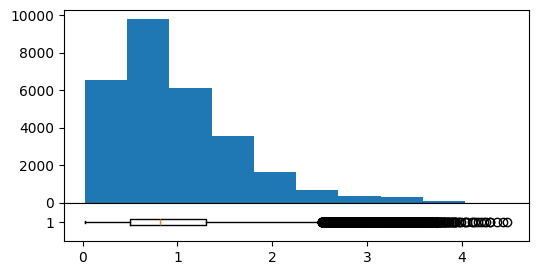

In [13]:
# Look at the distance between each piperidine
array1 = np.expand_dims( CoM_array, axis = (1,))
array2 =  np.expand_dims( CoM_array, axis = (0,))
array3 = array1 - array2
array4 = np.linalg.norm( array3, axis = 2 )
array5 = np.triu( array4, k=0)
array6 = np.matrix.flatten(array5)
array6 = array6[ np.nonzero(array6)]

fig, ax = plt.subplots( 2, 1, figsize = (6, 3), sharex=True, gridspec_kw={"height_ratios":[5,1]} ) 
# gs = gridspec.GridSpec( 2,1, height_ratios=(2,1) )
ax[0].hist( array6 )
ax[1].boxplot( array6, vert = False)
plt.subplots_adjust( hspace=0)
plt.show()

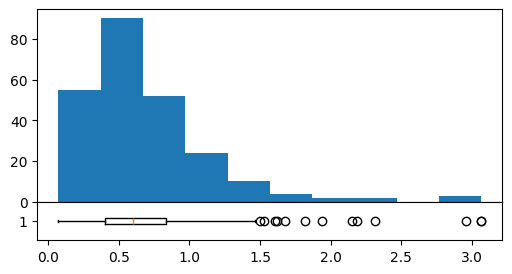

In [14]:
# Calculate mean center of mass for ligands without multiplicity
mean_CoM = CoM_array.mean( axis=0)
gemmi_mean_CoM = gemmi.Position( *mean_CoM.tolist() )

fig, ax = plt.subplots( 2, 1, figsize = (6, 3), sharex=True, gridspec_kw={"height_ratios":[5,1]} ) 
ax[0].hist( np.linalg.norm(CoM_array - mean_CoM, axis = 1) )
ax[1].boxplot( np.linalg.norm(CoM_array - mean_CoM, axis = 1), vert = False)
plt.subplots_adjust( hspace=0)
plt.show()


All CoM are within the same space

347


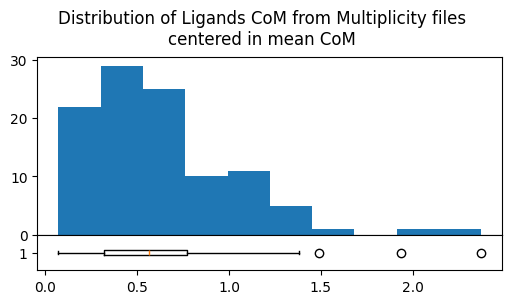

In [15]:
# Get ligand with shortest CoM from mean CoM
count = 0
dataset_names = list()
lst_CoM_dist = dict()
for dataset, lst_subsets in multiple_datasets.items():
    subset_names = sorted( lst_subsets )

    closest_subset_name = subset_names[0]
    closest_subset_obj = loadPDB( piperid_dir.joinpath( f"{subset_names[0]}",f"{subset_names[0]}_ligand.pdb") )
    closests_CoM = flatten_pdb( closest_subset_obj, "chain")[0].calculate_center_of_mass().dist(gemmi_mean_CoM)

    for subset_name in subset_names:
        tmp_lig_pdb = loadPDB( piperid_dir.joinpath( f"{subset_name}",f"{subset_name}_ligand.pdb"))
        CoM = flatten_pdb( tmp_lig_pdb, "chain")[0].calculate_center_of_mass()

        if CoM.dist( gemmi_mean_CoM ) < closests_CoM:
            closests_CoM = CoM.dist( gemmi_mean_CoM )
            closest_subset_name = subset_name
            closest_subset_obj = tmp_lig_pdb

    lst_piperids[closest_subset_name] = closest_subset_obj
    lst_CoM_dist[closest_subset_name] = closests_CoM

print( len( lst_piperids))

fig, ax = plt.subplots( 2, 1, figsize = (6, 3), sharex=True, gridspec_kw={"height_ratios":[5,1]} ) 
lst_CoM_dist = [ closests_CoM for closests_CoM in lst_CoM_dist.values()]
ax[0].hist( lst_CoM_dist)
ax[1].boxplot( lst_CoM_dist, vert = False)
plt.subplots_adjust( hspace=0, top = 0.82)
plt.suptitle("Distribution of Ligands CoM from Multiplicity files\ncentered in mean CoM")
plt.show()



#### Get Updated Center of Mass

In [16]:
updated_CoM_array = np.array( [ flatten_pdb(  lig, "chain")[0].calculate_center_of_mass().tolist() for lig in lst_piperids.values()  ] )
updated_mean_CoM = updated_CoM_array.mean( axis=0)
updated_gemmi_mean_CoM = gemmi.Position( *updated_mean_CoM.tolist() )

### - 1.2: Get Index for amino acids in the Binding Site

<details open>
<summary> Steps: </summary>

- Pick a reference protein and filter it

    - Reference Protein (A0926) only has one subset

    - Reference Protein ligand binds closests to one of the protein chains (see Image bellow)
    
    - Extract the chain which the binding site closest to the piperidines

- Get Ref Prot Amino Acids Indexes within 4 Angstorms from any Piperidine

</details>

#### Image of Reference Protein PDB File


<img src="../../../../images/piperid/reference_prot.png" width="7%" >

#### Get Index for amino acids in the Binding Site


In [17]:
# Get amino 
from xaidar.data.molecModels import sele_closest_Chain, clear_empty
ref_pdb = loadPDB( rootdir.joinpath("data/ev2a/fragalysis/02-chemofint/reference/A0926a.pdb") )
# get_pdb_stats( ref_pdb)

ref_lig = sele_pdb( ref_pdb, sele_Lig)
ref_lig_CoM = flatten_pdb( ref_lig, "chain")[0].calculate_center_of_mass()

ref_prots = sele_pdb(ref_pdb, sele_AA )
closest_chain = sele_closest_Chain(flatten_pdb( ref_prots, "chain"), ref_lig_CoM )
# print( "\n############\nClosest Prot Chain to Lig: ",closest_chain[0].name)

ref_prot = createPDB(chainList = closest_chain )
ref_prot = clear_empty( ref_prot )
# get_pdb_stats( ref_prot)

In [18]:
from xaidar.data.molecModels import get_pairwise_dist
ligs_datasets, ligs_res_lst = zip( *[[dataset, flatten_pdb(lig_obj, "residue")[0] ] for dataset, lig_obj in lst_piperids.items() ])
print( len(ligs_datasets), len(ligs_res_lst))
print( ligs_datasets[0], ligs_res_lst[0])

ref_prot_chains = flatten_pdb( ref_prot, "chain")


activesite_aa_set = set()
activesite_aa_set_idx = set()
activesite_aa_per_dataset = defaultdict( list)
for chain in ref_prot_chains:                                                       # There is only one chain
                                                                                    # First Filter By Residue Distance
    res_CoMs = get_res_CoM( chain.whole() )
    res_lst  = [ (idx, res) for idx, res in enumerate(chain.whole()) if np.linalg.norm( res_CoMs[idx] - updated_mean_CoM) < 15.0 ]
    for res_idx, prot_res in res_lst:                                                    # 
        res_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  prot_res] )
                                                                                    # Then, filter by atom distance
        for lig_res, lig_dataset_name in zip(ligs_res_lst,ligs_datasets ):          # Ligands
          lig_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  lig_res] )
          if np.min( get_pairwise_dist(res_atom_pos, lig_atom_pos) ) < 4.0:         # Amino acids within 4A of ligand
              activesite_aa_set.add( prot_res )
              activesite_aa_set_idx.add(res_idx)
              activesite_aa_per_dataset[lig_dataset_name].append( prot_res ) 

print(sorted([ (res.name, res.seqid.num) for res in activesite_aa_set], key = lambda res: res[1] ))
print( activesite_aa_set_idx)

347

 347
A0926a 250(LIG)
[('HIS', 21), ('ASP', 39), ('VAL', 84), ('GLU', 85), ('ALA', 86), ('SER', 87), ('GLU', 88), ('TYR', 89), ('TYR', 90), ('ARG', 93), ('GLN', 95), ('SER', 105), ('GLU', 106), ('PRO', 107), ('GLY', 108), ('ASP', 109), ('CYS', 110), ('VAL', 124), ('SER', 125), ('THR', 126), ('GLY', 127), ('GLY', 128), ('ASN', 129)]
{14, 32, 77, 78, 79, 80, 81, 82, 83, 86, 88, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122}


### - Filter Piperidine Proteins

So far we have filter the subsets so that we have the subset where the piperidine binds at the binding site

Now, we gonna filter those subsets with multiple proteins, by picking the chain with the Binding Site Residues CoM closest to the Piperidine CoM

Why we use indexes to filter?

- Previous analysis (02.2) shows that when aligned all proteins have the same starting point, that there is no deletions or insertions between the proteins up untill the index 132.

In [19]:
def sele_chain_name( lst_chain: list[gemmi.Chain], level = False, chain_name: 
                                str | list[str]  = None):
    """Helper function of sele_pdb, used to extract one or several
    chains into a pdb object based off of their
    """
    if level: return "chain"
    if isinstance( chain_name, str): chain_name = list(chain_name )
    return [ chain for chain in lst_chain if chain.name in chain_name]


lst_subsets = list(lst_piperids.keys())
lst_pip_prots = dict()


for subset in lst_subsets:
    pip_pdb = loadPDB( piperid_dir.joinpath( f"{subset}/{subset}.pdb" ) )
    pip_prot = sele_pdb(pip_pdb, sele_AA)

    if len( pip_prot[0]) > 1:                                                  
        shortest_dist_from_pip_mean_CoM = 100000000                             # Set arbitrarily large number so that any 
        for chain in pip_prot[0]:                                               # Check if there are chains in subset closer to 
            prot_res_lst = chain.whole()                                        # Get list of all residues
            prot_bind_site_res = [ res for id , res in 
                enumerate( prot_res_lst ) if id in activesite_aa_set_idx]       # Get binding site amino acids only 
            prot_bind_site_chain = gemmi.Chain("A")                             # Create an emtpy gemmi obj to save residues
            prot_bind_site_chain.append_residues(prot_bind_site_res)            # Save list of residues to gemmi obj
            prot_bind_site_chain_CoM = prot_bind_site_chain.calculate_center_of_mass()  # Get center of mass of binding
            dist_from_pip_mean_CoM = updated_gemmi_mean_CoM.dist( prot_bind_site_chain_CoM)
            if dist_from_pip_mean_CoM < shortest_dist_from_pip_mean_CoM:
                shortest_chain_name = chain.name


        pip_prot = sele_pdb( pip_prot, sele_chain_name, chain_name = shortest_chain_name ) 
        pip_prot = clear_empty( pip_prot)
        lst_pip_prots[subset] = pip_prot # {f"Chain_{pip_prot[0][0].name}": pip_prot}

    elif len( pip_prot[0]) == 1:
        lst_pip_prots[subset] = pip_prot # {f"Chain_{pip_prot[0][0].name}": pip_prot}
    else:
        Exception( f"There are no AA chains in dataset:  {subset}")

print( len(lst_pip_prots))

347


### - Filter Non-Piperidine Proteins -> Chain with CoM closests to Ref Protein CoM

Per dataset:

- Check if one subset with one chain

    IF not:

    - 

- Keep track on the variation of CoM and rmsd between chains in the same dataset


- Get one protein per dataset

        - In some cases there are: several subsets per dataset & several protein chains per subset
    
    - Method:

        - Get protein chain from all chains and all subsets, which Center of Mass is closest to the Reference Center of Mass

        - If protein has ligand binding in multiple sites, make sure you move them to the 

            - Use crystallographic data and align with reference aligned data

In [20]:
from xaidar.data.molecModels import sele_chain_idx

chem_series_dirs = ["fragscreen", "nonactivesite"]
rootdir.joinpath("data/ev2a/fragalysis/02-chemofint")
ref_prot
ref_prot_CoM = flatten_pdb( ref_prot, "chain")[0].calculate_center_of_mass()


def get_closest_prot(subset_name, ref_prot_CoM ):
    """
    Per subset of data, select the protein chain with the CoM closests to the
    reference protein chain CoM.
    """
    pdb = loadPDB( chem_series_dir.joinpath( subset_name, f"{subset_name}.pdb") )
    prots = sele_pdb( pdb, sele_AA)

    if len(prots[0]) == 1:
        prot_CoM = flatten_pdb( prots, "chain")[0].calculate_center_of_mass()
        CoM_diff = prot_CoM.dist( ref_prot_CoM )
        return prots, CoM_diff

    elif len(prots[0]) > 1:
        lst_prots = [ sele_pdb( prots, sele_chain_idx, lst_idx = [idx] )
                        for idx in range( len(prots[0]) )  ]

        shortest_dist_ref = 100000000
        for prot in lst_prots:
            
            prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
            CoM_diff = prot_CoM.dist( ref_prot_CoM )
            if CoM_diff < shortest_dist_ref:
                shortest_dist_ref = CoM_diff
                closest_prot = prot
     
        return closest_prot, shortest_dist_ref
                           
    else:
        raise Exception( "The following subset is missing proteins: {subset}")


proteins_dict = dict( )
for chem_series_type in chem_series_dirs:
    proteins_dict[chem_series_type] =  dict()

    chem_series_dir = rootdir.joinpath("data/ev2a/fragalysis/02-chemofint", chem_series_type)
    
    dataset_subset_dir = defaultdict(list)                                          # Get Dataset and List of Subsets
    for subset in chem_series_dir.iterdir(): 
        if subset.is_dir: dataset_subset_dir[ subset.name[:-1]].append(subset.name)
    
    for dataset, lst_subsets in dataset_subset_dir.items():
        if len(lst_subsets) == 1:
            subset = lst_subsets[0]
            closest_subset_prot, _ = get_closest_prot(subset, ref_prot_CoM)
            proteins_dict[ chem_series_type][subset] = closest_subset_prot

        elif len(lst_subsets) > 1:
            shortest_dist = 100000000
            for subset in lst_subsets:
                closest_subset_prot, shortest_subset_dist = get_closest_prot( subset, ref_prot_CoM, )
                if shortest_subset_dist < shortest_dist:
                    closest_subset = subset
                    closest_prot = closest_subset_prot
            proteins_dict[ chem_series_type][closest_subset] = closest_prot
        else:
            raise Exception( "The following dataset is missing subsets: {dataset}")

In [21]:
print( "Length of frag screen unique subsets: {}".format( len( proteins_dict["fragscreen"] )))
print( "Length of nonactive unique subsets: {}".format( len( proteins_dict["nonactivesite"] )))        

print("#########")
print("Length of frag screen unique subsets: {}".format(
    len( set( [ item.name[:-1] for item in rootdir.joinpath("data/ev2a/fragalysis/02-chemofint","fragscreen").iterdir()] )) 
) )
print( "Length of nonactive unique subsets: {}".format( 
        len( set( [ item.name[:-1] for item in rootdir.joinpath("data/ev2a/fragalysis/02-chemofint","nonactivesite").iterdir()] )) 
) ) 

Length of frag screen unique subsets: 41
Length of nonactive unique subsets: 79
#########
Length of frag screen unique subsets: 41
Length of nonactive unique subsets: 79


#### Add Piperidine to General Protein Dictionary

In [22]:
proteins_dict["piperidine"] = lst_pip_prots

In [23]:
# proteins_dict["piperidine"]

In [24]:
from pathlib import Path
from xaidar.data.molecModels import savePDB

filter_dir = rootdir.joinpath( "data/ev2a/fragalysis/03-filterdata/prots")
filter_dir.mkdir( parents= True, exist_ok= True)

count = 0
for prot_type in proteins_dict.values():
    for i, prot in enumerate(prot_type.values()):
        savePDB(prot, filter_dir.joinpath( f"ev2a{count+i}.pdb") )

    
    count += len(prot_type)



### **Output**:

-  `proteins_dict` that contains one protein per ligand 

    - Format: `proteins_dict[chem group][datasubset code]` -> gemmi.pdb

### Save the output object into a pickle file

In [31]:
with open( rootdir.joinpath("data/ev2a/fragalysis/04-closestligtocentralprot/prot_dict.pkl"), "wb") as f:
    pkl.dump( proteins_dict, f)


## - 1.3: Identify with Multiple Occupancies


For backbone atoms and b-carbon:

- Assume a simple guassian distribtuion

- Since we will be calculating **rmsf**, we just do a weighted average of positions based on the occupancies for each atom with alternative locations `altloc`.

For further carbons and heavy atoms:

- Assume a mix guassian distribution

- We compile a list of multiple occupancies with their coordinates per amino acid per protein.

 - `still on the workings!!!`

#### 1.3.1 - Looking at fractional occupancies and multiple locations atoms

In [25]:
# Identifying problems with c_alpha_matrix due to multiple locations per atom
c_alpha_matrix = [ [ at.pos.tolist()  for res_idx, res in enumerate( proteins_dict[chem_series][subset][0][0].whole()  ) for at in res if at.name == "CA" and res_idx < 132]
           for chem_series in proteins_dict.keys() 
           for subset in proteins_dict[chem_series] ]
print("# 1st Dimension - Number of Proteins ###")          
print( np.sum( [ len(proteins_dict[series]) for series in proteins_dict.keys() ] ) )
print( len(c_alpha_matrix) )
print("# 2nd Dimension - Number of Residues ###")
numb_resi = set( [ len(lst_residues) for lst_residues in c_alpha_matrix])
numb_resi_dict = { resi_count : [ (idx, lst_residues) for idx, lst_residues in enumerate( c_alpha_matrix) if len(lst_residues) == resi_count] for resi_count in numb_resi}
print("  (# Res, # Prots):\n    ",*[(key, len(values)) for key, values in numb_resi_dict.items()] )

print( numb_resi_dict[140][0][0])
# Look at occ == 1
c_alpha_matrix = [ [ at.pos.tolist()  for res_idx, res in enumerate( proteins_dict[chem_series][subset][0][0].whole()  ) for at in res if at.name == "CA"and at.occ == 1 and res_idx < 132]
           for chem_series in proteins_dict.keys() 
           for subset in proteins_dict[chem_series] ]

numb_resi_dict = { resi_count : [ (idx, lst_residues) for idx, lst_residues in enumerate( c_alpha_matrix) if len(lst_residues) == resi_count] for resi_count in numb_resi}
print("  Distribution for proteins with alpha C with one occ only:")
print( "    ",*[(key, len(values)) for key, values in numb_resi_dict.items()] )
print("# Look at specifc case")
# Look at one protein with specif
flat_dict = [ (chem_series, subset, [ proteins_dict[chem_series][subset][0][0].whole() ],  [ at.pos.tolist()  for res_idx, res in enumerate( proteins_dict[chem_series][subset][0][0].whole()  ) for at in res if at.name == "CA" and res_idx < 132])
        for chem_series in proteins_dict.keys() 
        for subset in proteins_dict[chem_series] ]
print(flat_dict[46])
print( len([ res  for res_idx, res in enumerate( flat_dict[46][3] ) if res_idx < 132] ))

print(len(flat_dict[46][3]))

print([ (res_idx, res.name, res.seqid.num, res.seqid )  for res_idx, res in enumerate( flat_dict[46][2][0] ) if res_idx < 132 and len( [ _ for at in res if at.name == "CA"]) > 1]  )

print( [ at.name for at in flat_dict[46][2][0][11]])
print([ at.occ for at in flat_dict[46][2][0][11]] )

# c_alpha_matrix = np.array( [ [ np.array(at.pos.tolist())  for res_idx, res in enumerate( proteins_dict[chem_series][subset][0][0].whole()  ) for at in res if at.name == "CA" and res_idx < 132]
#            for chem_series in proteins_dict.keys() 
#            for subset in proteins_dict[chem_series] 
          
#             ] )

# print( c_alpha_matrix.__len__() )

# 1st Dimension - Number of Proteins ###
467
467
# 2nd Dimension - Number of Residues ###
  (# Res, # Prots):
     (132, 17) (133, 253) (134, 114) (135, 59) (136, 12) (137, 9) (138, 2) (140, 1)
46
  Distribution for proteins with alpha C with one occ only:
     (132, 14) (133, 0) (134, 0) (135, 0) (136, 0) (137, 0) (138, 0) (140, 0)
# Look at specifc case
('nonactivesite', 'A7501b', [<gemmi.ResidueSpan of 140: Bxp [1(SER) 2(GLY) 3(ALA) ... 140(GLU)]>], [[21.538, 13.778, 24.475], [23.219, 11.726, 21.763], [23.57, 11.214, 18.046], [24.392, 8.573, 15.412], [27.321, 9.482, 13.119], [27.236, 7.392, 9.898], [29.107, 8.469, 6.748], [28.563, 12.227, 6.434], [25.31, 12.203, 8.373], [24.405, 13.071, 11.976], [21.132, 11.559, 13.219], [19.632, 13.261, 16.281], [19.662, 13.291, 16.28], [16.286, 13.552, 18.059], [14.481, 16.291, 16.136], [13.437, 17.952, 19.406], [17.13, 18.291, 20.366], [18.492, 19.457, 16.978], [20.644, 22.584, 17.073], [20.373, 25.646, 14.794], [23.489, 24.245, 12.931], [23.466,

In [26]:
# Looking at example atoms with single and multiple locations / fractional or whole occupancies
ref = proteins_dict["piperidine"]["A0926a"]
multi_occ_prot = proteins_dict["nonactivesite"]["A7501b"]
res_lst = multi_occ_prot[0][0].whole()
res = res_lst[11]
seqid = res.seqid
bb_n = res["N"]
print(bb_n.__len__())
alpha_c = res["CA"]
atom = res[2]
print( type(alpha_c))
print( type(bb_n))
print( len(alpha_c))

print(atom)
print(atom.altloc)
print(atom.has_altloc())

1
<class 'gemmi.AtomGroup'>
<class 'gemmi.AtomGroup'>
2
<gemmi.Atom CB.A at (20.2, 14.7, 16.6)>
A
True


In [27]:
# Testing weighted average code
res_gp = res["CA"]
if len(res_gp) == 2:
    occ, pos = list( zip( *[ (atom.occ, atom.pos.tolist() )for atom in res_gp] ) )
    occ, pos = np.array(occ), np.array( pos)
    new_pos = (pos[1] - pos[0])*occ[1] + pos[0]
    print( pos, new_pos) 
if len(res_gp) > 1:
    occ, pos =  list( zip( *[ ( [atom.occ], atom.pos.tolist() )for atom in res_gp] ) )
    occ, pos = np.array(occ), np.array( pos)
    CoM =  np.sum( pos*occ, axis = 0)

    print("#########")
    print( pos,"\n\n", occ,"\n\n", pos*occ, "\n\n", np.sum( pos*occ, axis = 0) )

    pass

[[19.632 13.261 16.281]
 [19.662 13.291 16.28 ]] [19.647  13.276  16.2805]
#########
[[19.632 13.261 16.281]
 [19.662 13.291 16.28 ]] 

 [[0.5]
 [0.5]] 

 [[9.816  6.6305 8.1405]
 [9.831  6.6455 8.14  ]] 

 [19.647  13.276  16.2805]


### 1.3.2 - Writing code to calculate weighted average location per amino acid per protein 

In [28]:
def mean_occ_loc( atoms: gemmi.AtomGroup):
    if not isinstance( atoms, gemmi.AtomGroup): raise Exception( "Must input gemmi.AtomGroup object type")
    if len(atoms) == 1: return np.array( atoms[0].pos.tolist() )
    elif len(atoms) < 1: raise Exception( "Input is empty")
    else:
        occ, pos =  list( zip( *[ ( [atom.occ], atom.pos.tolist() )for atom in atoms] ) )
        occ, pos = np.array(occ), np.array( pos)
        new_pos =  np.sum( pos*occ, axis = 0)
        return new_pos

c_alpha_matrix = np.array( [ [ mean_occ_loc(res["CA"]) for res_idx, res in enumerate( proteins_dict[chem_series][subset][0][0].whole()  )  if res_idx < 132]
           for chem_series in proteins_dict.keys() 
           for subset in proteins_dict[chem_series] ] )
print(c_alpha_matrix.shape)

print("# 1st Dimension - Number of Proteins ###")          
print( np.sum( [ len(proteins_dict[series]) for series in proteins_dict.keys() ] ) )
print( len(c_alpha_matrix) )
print("# 2nd Dimension - Number of Residues ###")
numb_resi = set( [ len(lst_residues) for lst_residues in c_alpha_matrix])
numb_resi_dict = { resi_count : [ (idx, lst_residues) for idx, lst_residues in enumerate( c_alpha_matrix) if len(lst_residues) == resi_count] for resi_count in numb_resi}
print("\t(# Res, # Prots): ",*[(key, len(values)) for key, values in numb_resi_dict.items()] )


(467, 132, 3)
# 1st Dimension - Number of Proteins ###
467
467
# 2nd Dimension - Number of Residues ###
	(# Res, # Prots):  (132, 467)
